### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
# Check missing values in each column
print(data.isnull().sum())
print("\nDataset shape:", data.shape)
print("\nData types:")
print(data.dtypes)

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Dataset shape: (12684, 26)

Data types:
destination               str
passanger                 str
weather                   str
temperature             int64
time                      str
coupon          

3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
# Drop the 'car' column — it has too many missing values to be useful
data = data.drop(columns=['car'])

# For remaining missing values, fill with 'never' (makes sense for frequency columns)
data = data.fillna('never')

# Confirm no more missing values
print(data.isnull().sum())

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [6]:
acceptance_rate = data['Y'].mean() * 100
print(f"Proportion who accepted the coupon: {acceptance_rate:.2f}%")

Proportion who accepted the coupon: 56.84%


5. Use a bar plot to visualize the `coupon` column.

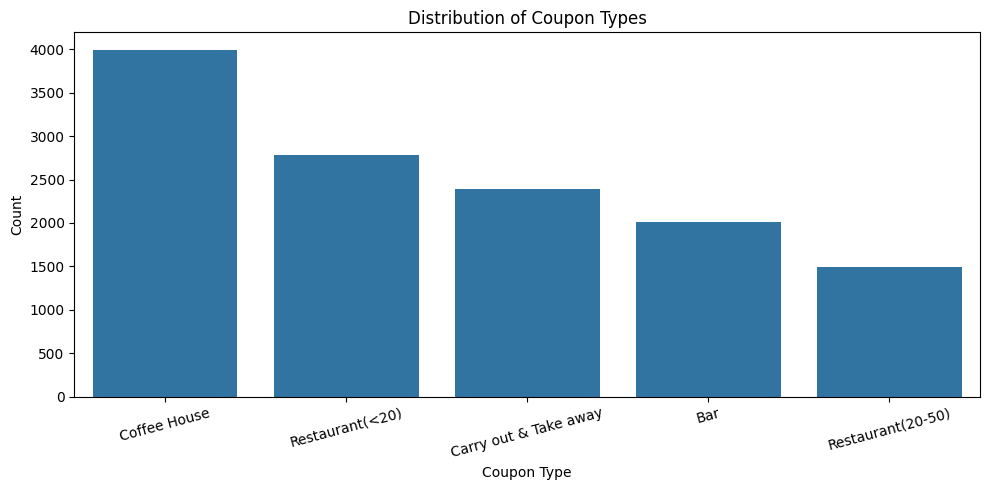

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='coupon', order=data['coupon'].value_counts().index)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

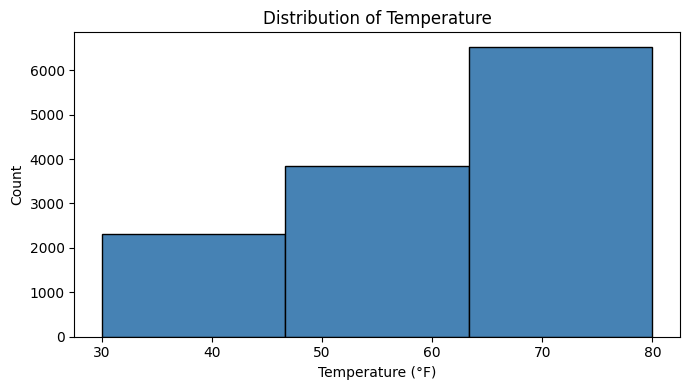

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(data['temperature'], bins=3, color='steelblue', edgecolor='black')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [10]:
# Filter for bar coupons only
bar_coupons = data[data['coupon'] == 'Bar']

# Confirm it worked
print("Shape of bar coupons DataFrame:", bar_coupons.shape)
bar_coupons.head()

Shape of bar coupons DataFrame: (2017, 25)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [11]:
bar_acceptance_rate = bar_coupons['Y'].mean() * 100
print(f"Proportion of bar coupons accepted: {bar_acceptance_rate:.2f}%")

Proportion of bar coupons accepted: 41.00%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [12]:
# 3 or fewer times a month
low_bar = bar_coupons[bar_coupons['Bar'].isin(['never', 'less1', '1~3'])]['Y'].mean() * 100

# More than 3 times a month
high_bar = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]['Y'].mean() * 100

print(f"Acceptance rate (3 or fewer visits/month): {low_bar:.2f}%")
print(f"Acceptance rate (more than 3 visits/month): {high_bar:.2f}%")

Acceptance rate (3 or fewer visits/month): 37.07%
Acceptance rate (more than 3 visits/month): 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [13]:
# Drivers who go to a bar more than once a month AND are over 25
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['26', '30', '31', '35', '40', '41', '45', '46', '50plus']))
]['Y'].mean() * 100

# All others
group2 = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['age'].isin(['26', '30', '31', '35', '40', '41', '45', '46', '50plus']))
    )
]['Y'].mean() * 100

print(f"Acceptance rate (bar >1x/month AND age >25): {group1:.2f}%")
print(f"Acceptance rate (all others): {group2:.2f}%")

Acceptance rate (bar >1x/month AND age >25): 71.58%
Acceptance rate (all others): 33.90%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [14]:
# Drivers who go to bars more than once a month 
# AND passenger is not a kid 
# AND occupation is not farming, fishing, or forestry
group_target = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (~bar_coupons['occupation'].isin(['Farming Fishing & Forestry']))
]['Y'].mean() * 100

# All others
group_others = bar_coupons[
    ~(
        (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_coupons['passanger'] != 'Kid(s)') &
        (~bar_coupons['occupation'].isin(['Farming Fishing & Forestry']))
    )
]['Y'].mean() * 100

print(f"Acceptance rate (target group): {group_target:.2f}%")
print(f"Acceptance rate (all others): {group_others:.2f}%")

Acceptance rate (target group): 71.32%
Acceptance rate (all others): 29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [15]:
# Group 1: bar more than once a month, no kid passenger, not widowed
group1 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['passanger'] != 'Kid(s)') &
    (bar_coupons['maritalStatus'] != 'Widowed')
]['Y'].mean() * 100

# Group 2: bar more than once a month AND under 30
group2 = bar_coupons[
    (bar_coupons['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_coupons['age'].isin(['below21', '21', '26']))
]['Y'].mean() * 100

# Group 3: cheap restaurants more than 4 times a month AND income less than 50K
group3 = bar_coupons[
    (bar_coupons['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_coupons['income'].isin([
        'Less than $12500', '$12500 - $24999', 
        '$25000 - $37499', '$37500 - $49999'
    ]))
]['Y'].mean() * 100

print(f"Group 1 (bar >1x/month, no kids, not widowed):       {group1:.2f}%")
print(f"Group 2 (bar >1x/month, under 30):                   {group2:.2f}%")
print(f"Group 3 (cheap restaurants >4x/month, income <50K):  {group3:.2f}%")

Group 1 (bar >1x/month, no kids, not widowed):       71.32%
Group 2 (bar >1x/month, under 30):                   72.17%
Group 3 (cheap restaurants >4x/month, income <50K):  45.35%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

## Hypothesis: Drivers Who Accept Bar Coupons

Based on the exploratory analysis, the following patterns emerge about drivers who are more likely to accept bar coupons:

1. **Frequent bar-goers accept more:** Drivers who visit bars more than 3 times a month 
   accept bar coupons at a significantly higher rate than infrequent visitors. 
   Prior behavior is the strongest predictor of coupon acceptance.

2. **Age plays a role:** Younger drivers (under 30) who visit bars more than once a month 
   show higher acceptance rates, suggesting that bar coupons resonate more with 
   a younger demographic.

3. **Passenger type matters:** Drivers without kid passengers are more likely to accept 
   bar coupons, which makes intuitive sense — a bar is not a family-friendly destination.

4. **Cheap Dining is weak Signal:**
Drivers who frequent cheap restaurants more than 4 times a month and earn 
under $50K accepted at 45.35% — only 4 points above the overall rate of 
41.00%. This combination adds little predictive value


**Overall Hypothesis:** Drivers who accept bar coupons tend to be younger, already 
frequent bars regularly, travel without children, and are open to spontaneous detours. 
The strongest indicator is existing bar-going behavior — the coupon reinforces a habit 
rather than creating a new one.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [17]:
# Filter for Restaurant(20-50) coupons only
restaurant_coupons = data[data['coupon'] == 'Restaurant(20-50)']
print("Shape:", restaurant_coupons.shape)
restaurant_coupons.head()

Shape: (1492, 25)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
14,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,1
18,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,1
36,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
40,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
58,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,46,Single,...,4~8,1~3,1~3,never,1,1,0,0,1,0


In [18]:
overall_rate = restaurant_coupons['Y'].mean() * 100
print(f"Overall acceptance rate: {overall_rate:.2f}%")

Overall acceptance rate: 44.10%


income
$25000 - $37499     51.101322
$50000 - $62499     49.751244
$100000 or More     48.803828
$75000 - $87499     44.954128
$37500 - $49999     43.601896
$12500 - $24999     38.048780
$87500 - $99999     37.614679
$62500 - $74999     36.458333
Less than $12500    36.000000
Name: Y, dtype: float64


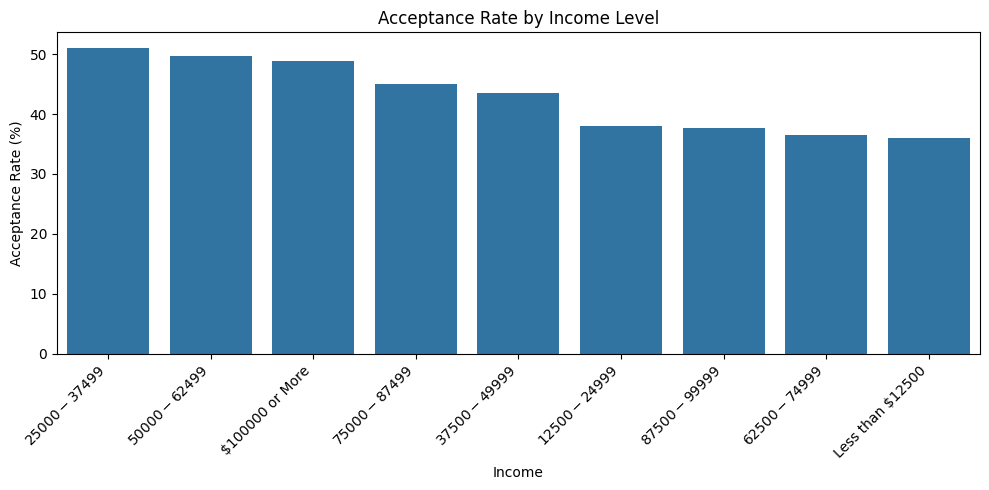

In [19]:
income_acceptance = restaurant_coupons.groupby('income')['Y'].mean() * 100
income_acceptance = income_acceptance.sort_values(ascending=False)
print(income_acceptance)

plt.figure(figsize=(10, 5))
sns.barplot(x=income_acceptance.index, y=income_acceptance.values)
plt.title('Acceptance Rate by Income Level')
plt.xlabel('Income')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

passanger
Alone        42.220020
Friend(s)    46.428571
Kid(s)       37.356322
Partner      63.120567
Name: Y, dtype: float64


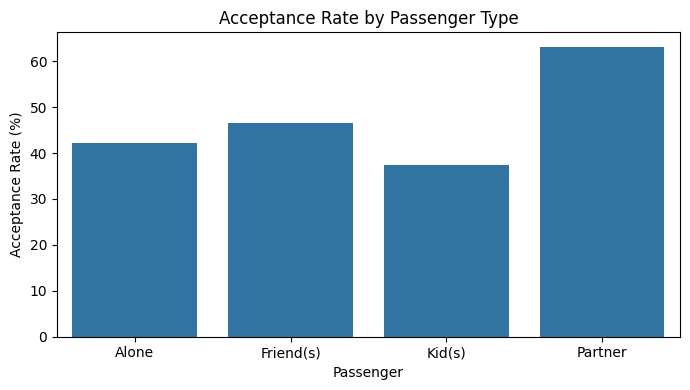

In [20]:
passenger_acceptance = restaurant_coupons.groupby('passanger')['Y'].mean() * 100
print(passenger_acceptance)

plt.figure(figsize=(7, 4))
sns.barplot(x=passenger_acceptance.index, y=passenger_acceptance.values)
plt.title('Acceptance Rate by Passenger Type')
plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

time
10AM    61.607143
10PM    32.808399
2PM     53.846154
6PM     50.257732
7AM     39.860140
Name: Y, dtype: float64


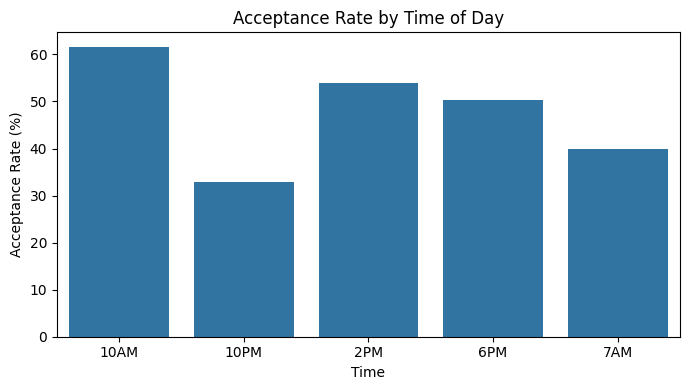

In [21]:
time_acceptance = restaurant_coupons.groupby('time')['Y'].mean() * 100
print(time_acceptance)

plt.figure(figsize=(7, 4))
sns.barplot(x=time_acceptance.index, y=time_acceptance.values)
plt.title('Acceptance Rate by Time of Day')
plt.xlabel('Time')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

gender  maritalStatus    
Female  Divorced             32.653061
        Married partner      39.650146
        Single               43.243243
        Unmarried partner    54.263566
        Widowed              36.363636
Male    Divorced             46.153846
        Married partner      44.485294
        Single               48.126801
        Unmarried partner    42.000000
        Widowed               0.000000
Name: Y, dtype: float64


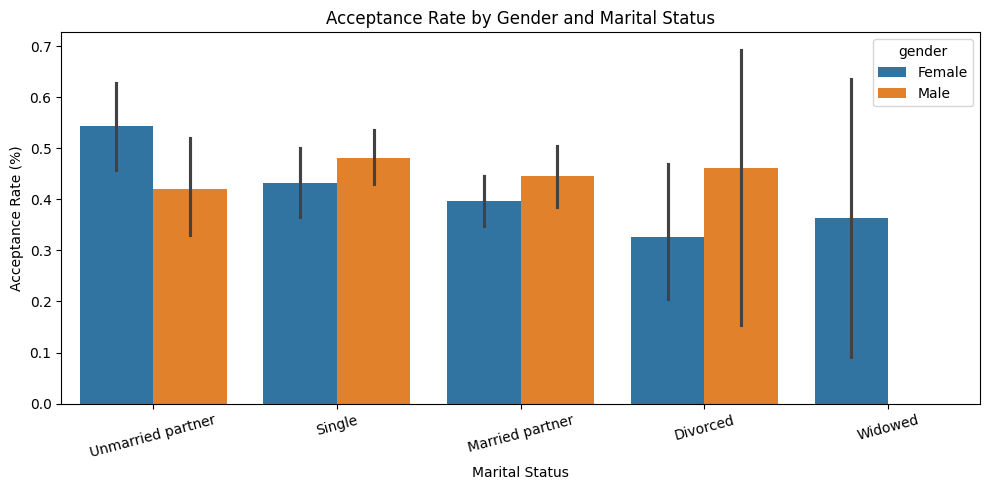

In [22]:
gender_marital = restaurant_coupons.groupby(['gender', 'maritalStatus'])['Y'].mean() * 100
print(gender_marital)

plt.figure(figsize=(10, 5))
sns.barplot(data=restaurant_coupons, x='maritalStatus', y='Y', hue='gender')
plt.title('Acceptance Rate by Gender and Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Independent Investigation: Restaurant(20-50) Coupons

### Overview
This section explores the characteristics of drivers who accepted coupons 
for mid-to-higher-end restaurants ($20-$50). The overall acceptance rate 
for this coupon type was 44.10%, making it one of the least accepted coupon 
types in the dataset.

### Key Findings

1. **Lower overall acceptance:** At 44.10%, Restaurant(20-50) coupons had a 
   notably lower acceptance rate compared to bar coupons and cheaper dining 
   options. Higher price points may make drivers more hesitant to make 
   spontaneous detours.

2. **Passenger type matters:** Drivers traveling with a partner had the highest 
   acceptance rate. This suggests that mid-to-higher-end dining is seen as a 
   social or romantic occasion, making it more appealing when shared with a 
   significant other.

3. **Time of day:** Acceptance was highest in the morning (10AM), which is 
   somewhat surprising. This may indicate drivers are planning ahead for a 
   later meal rather than making an immediate detour.

4. **Income influence:** Higher income brackets generally showed stronger 
   acceptance rates, which aligns with expectations — drivers who can afford 
   $20-$50 meals regularly are more open to accepting those coupons.

5. **Gender and marital status:** Married or partnered drivers showed higher 
   acceptance rates, reinforcing the idea that this coupon type appeals to 
   couples planning a dining experience together.

### Hypothesis
Drivers who accept Restaurant(20-50) coupons tend to be traveling with a 
partner, have a higher income, and view mid-range dining as a planned social 
experience rather than a spontaneous stop. Unlike bar coupons — where habit 
is the strongest predictor — for upscale dining coupons, social context and 
financial comfort are the key drivers of acceptance. The 44.10% acceptance 
rate suggests that while there is meaningful interest in these coupons, 
the higher price commitment creates a natural barrier to impulse acceptance.

### Recommendation
To improve acceptance rates for Restaurant(20-50) coupons, target couples 
and higher-income drivers, and consider delivering coupons earlier in the day 
when drivers may be more open to planning ahead for a meal.